In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# add code directory to path
import sys
import os
sys.path.append(os.path.join(os.path.abspath(''), 'code'))

In [3]:
from external.spherical_kmeans import SphericalKMeans
from sklearn.cluster import KMeans

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [5]:
from config import load_config

In [6]:
config = load_config("configs/config_PTE.yaml")
sequences_df = pd.read_csv(config["dataset_path"])

Loaded configuration:
  root_path: /home/labs/fleishman/omripo/Projects/adaptive_learning

  data_dir_name: data

  pretraining_dir_name: pretraining

  bootstrap_dir_name: bootstrap

  results_dir_name: results

  enzyme: PTE

  substrate: malathion

  dataset_filename: adaptive_learning_stage_0.csv

  tag: adaptive

  weights_filename: final_model.pt

  model_type: plm

  finetune: False

  opmode: mean

  train_type: msa_backbone

  cluster_method: kmeans

  nmuts_column: num_muts

  sequence_column_name: full_seq

  activity_column_name: inactive

  first_column_name: I106

  last_column_name: M317

  plm_name: esm2_t12_35M_UR50D

  ref_seq: DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALAEKAVRGLRRARAAGVRTIVDVSTFDIGRDVSLLAEVSRAADVHIVAATGLWFDPPLSMRLRSVEELTQFFLREIQYGIEDTGIRAGIIKVATTGKATPFQELVLKAAARASLATGVPVTTHTAASQRDGEQQAAIFESEGLSPSRVCIGHSDDTDDLSYLTALAARGYLIGLDHIPHSAIGLEDNASASALLGIRSWQTRALLIKALIDQGYMKQILVSNDWLFGFSSYVTNIMDVMDRVNPDGMAFIPLRVIPFLREKGVPQETLAGITVTNPARFLSPTLRAS

  bootstrap_i

In [13]:
# create a 3d dataset of points on a unit sphere, with 3 clusters centered around 3 angles
n_points = 300
angles = [0, 2*np.pi/3, 4*np.pi/3]
data = []
for angle in angles:
    for _ in range(n_points // len(angles)):
        theta = angle + np.random.normal(0, 0.1)
        phi = np.random.uniform(0, 0.01)  # small variation in polar angle
        x = np.sin(phi) * np.cos(theta)
        y = np.sin(phi) * np.sin(theta)
        z = np.cos(phi)
        data.append([x, y, z])

# make the magnitude of each point very small so that only the angles matter
uniform_magnitudes = np.random.uniform(0.01, 0.1, size=len(data))
data = np.array(data)
data = data * uniform_magnitudes[:, np.newaxis]

In [ ]:
# plot the data on an interactive 3d scatter plot
df = pd.DataFrame(data, columns=['x', 'y', 'z'])
fig = px.scatter_3d(df, x='x', y='y', z='z', opacity=0.7)
fig.show()

In [18]:
# perform regular kmeans clustering
kmeans = KMeans(n_clusters=3)
kmeans_labels = kmeans.fit_predict(data)
# plot the clusters in 3d
df['kmeans_cluster'] = kmeans_labels
fig = px.scatter_3d(df, x='x', y='y', z='z', color='kmeans_cluster', opacity=0.7)
fig.show()

In [20]:
# perform spherical k-means clustering
n_clusters = 3
spherical_kmeans = SphericalKMeans(n_clusters=n_clusters, max_iter=100, tol=1e-6)
spherical_kmeans.fit(data)
spherical_labels = spherical_kmeans.labels_
# plot the spherical k-means clusters in 3d
df['spherical_kmeans_cluster'] = spherical_labels
fig = px.scatter_3d(df, x='x', y='y', z='z', color='spherical_kmeans_cluster', opacity=0.7)
fig.show()

In [21]:
representatives_df = pd.read_csv(f"{config['results_path']}/cluster_representative_sequences_mean_naive_spherical_kmeans_regular_embeddings.csv")

In [22]:
sequences = representatives_df["full_seq"]
sequences = sequences.apply(lambda x: "".join([x[i - 1] for i in config["pos_to_use"]]))

In [14]:
import logomaker as lm

[Text(0, 0, '106'),
 Text(1, 0, '132'),
 Text(2, 0, '254'),
 Text(3, 0, '257'),
 Text(4, 0, '271'),
 Text(5, 0, '303'),
 Text(6, 0, '306'),
 Text(7, 0, '317')]

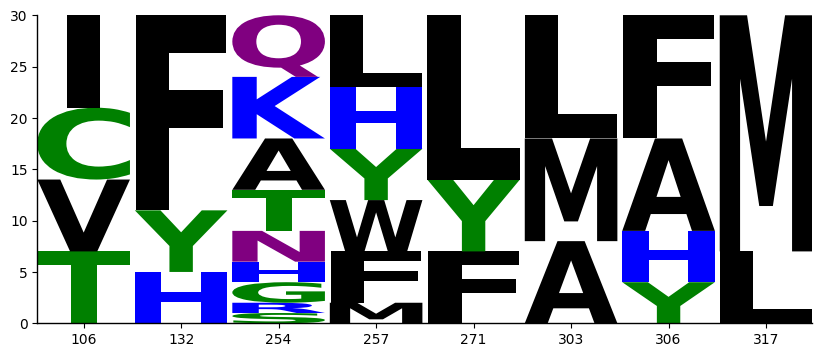

In [23]:
# create logoplot of the sequences
plt.figure(figsize=(10, 4))
ax = plt.subplot(1, 1, 1)
count_matrix = lm.alignment_to_matrix(sequences=sequences, to_type="counts")
# create a logo
logo = lm.Logo(count_matrix, color_scheme="chemistry", ax=ax)
logo.style_spines(visible=False)
logo.style_spines(spines=["left", "bottom"], visible=True)
# set x-ticks to be the position in the sequence + 34
ax.set_xticks(range(len(config["pos_to_use"])))
ax.set_xticklabels([p + 34 for p in config["pos_to_use"]])
# logo.style_xticks(rotation=90, fmt="%d", anchor=0)